In [7]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
print("All Libraries are imported successfully")

All Libraries are imported successfully


In [3]:
df =pd.read_csv('upi_transactions_2024.csv')
print("shape:", df.shape)
df.head()


shape: (250000, 17)


,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,08-10-2024 15:17,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,11-04-2024 06:56,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,02-04-2024 13:27,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,07-01-2024 10:09,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,23-01-2024 19:04,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [5]:
print("Total Transactions:",len(df))
print("Total Amount:", df['amount (INR)'].sum())
print("Success Rate:", round(df['transaction_status'].value_counts(normalize=True)['SUCCESS']*100,2),"%")
print("Fraud Transactions:", df['fraud_flag'].sum())
print("Avg Transaction Value:", round(df['amount (INR)'].mean(), 2))

Total Transactions: 250000
Total Amount: 327939009
Success Rate: 95.05 %
Fraud Transactions: 480
Avg Transaction Value: 1311.76


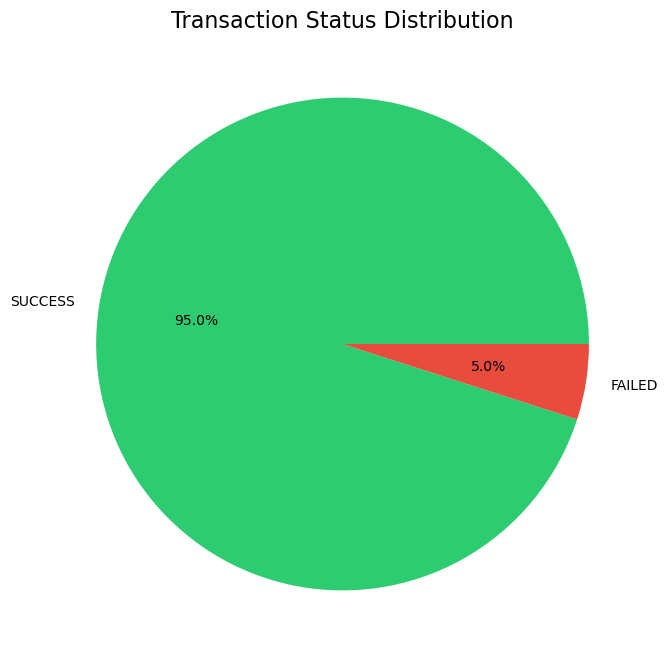

In [6]:
status_counts = df['transaction_status'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(status_counts.values,
        labels=status_counts.index,
        autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c','#f39c12'])
plt.title('Transaction Status Distribution', fontsize=16)
plt.show()

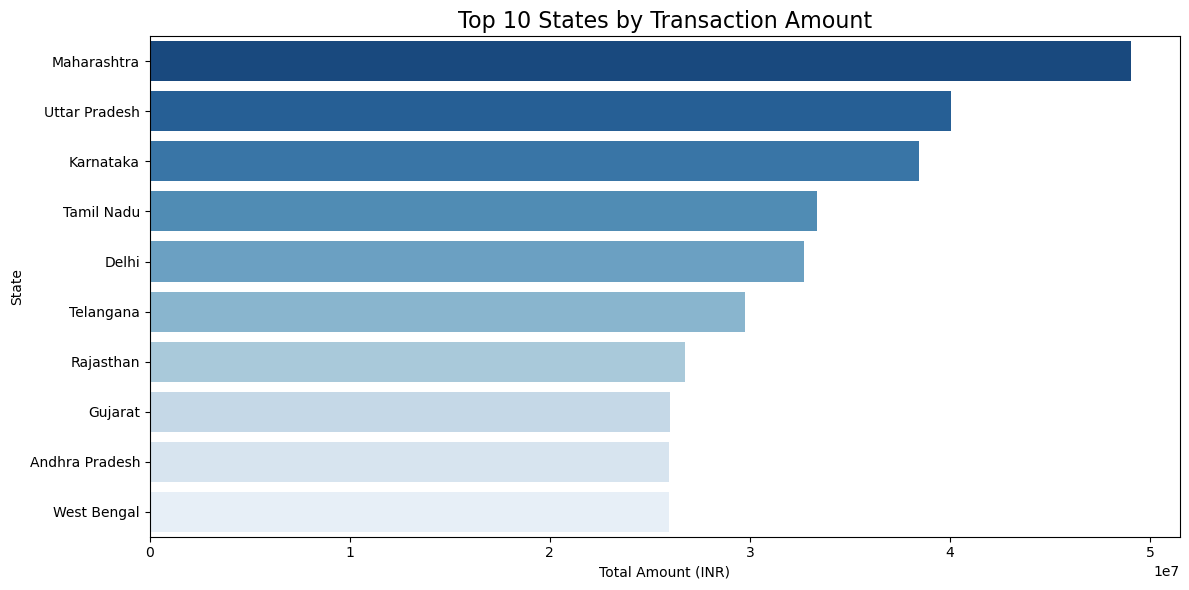

In [7]:
top_states = df.groupby('sender_state')['amount (INR)'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_states.values,
            y=top_states.index,
            hue=top_states.index,
            palette='Blues_r',
            legend=False)
plt.title('Top 10 States by Transaction Amount', fontsize=16)
plt.xlabel('Total Amount (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

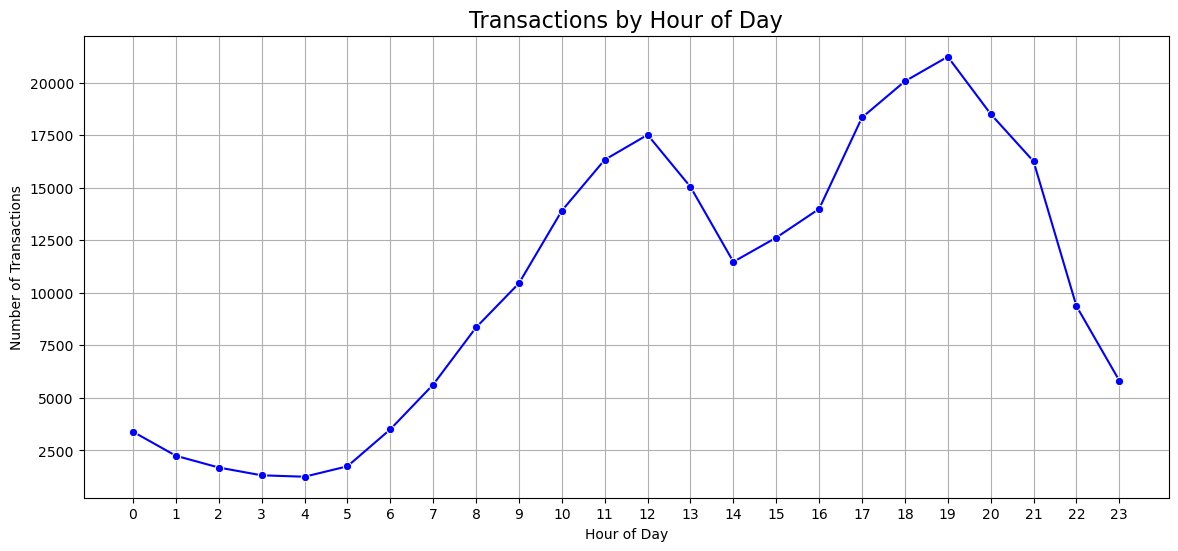

In [9]:
hourly = df.groupby('hour_of_day').size()

plt.figure(figsize=(14,6))
sns.lineplot(x=hourly.index,
             y=hourly.values,
             marker='o',
             color='blue')
plt.title('Transactions by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

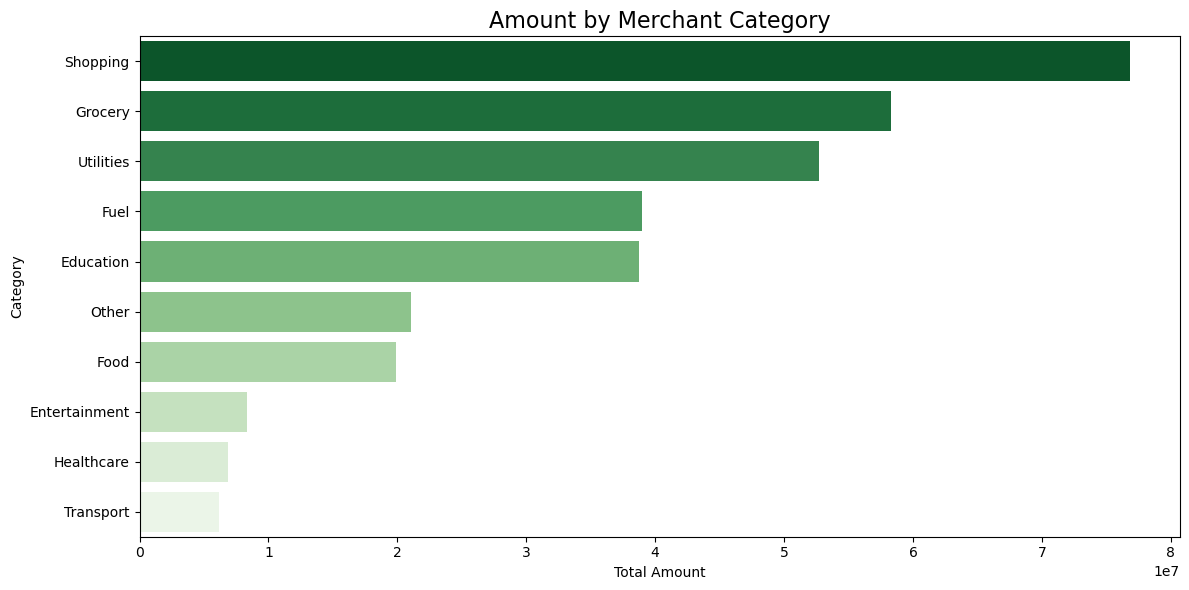

In [10]:
category = df.groupby('merchant_category')['amount (INR)'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=category.values,
            y=category.index,
            hue=category.index,
            palette='Greens_r',
            legend=False)
plt.title('Amount by Merchant Category', fontsize=16)
plt.xlabel('Total Amount')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

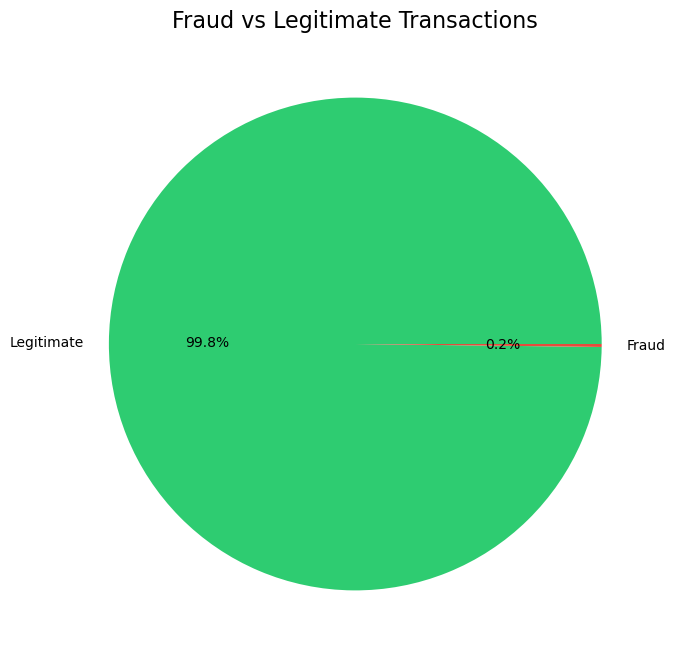

In [11]:
fraud_counts = df['fraud_flag'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(fraud_counts.values,
        labels=['Legitimate','Fraud'],
        autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c'])
plt.title('Fraud vs Legitimate Transactions', fontsize=16)
plt.show()

In [ ]:
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

day_counts = df.groupby('day_of_week').size().reindex(day_order)

plt.figure(figsize=(12,6))
sns.barplot(x=day_counts.index,
            y=day_counts.values,
            hue=day_counts.index,
            palette='Oranges_r',
            legend=False)
plt.title('Transactions by Day of Week', fontsize=16)
plt.xlabel('Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'Column not found: transaction_id'